In [2]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

In [3]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Projects/Satellite_Image_Classification/EuroSAT.zip"

import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/EuroSAT")

# I. Data Exploration
* In this project, I'll be exploring the EUROSAT dataset. The EUROSAT dataset is composed of images taken from the Sentinel-2 satellite. This dataset lists images of the earth's surface into 10 different land cover labels. For this project, I will build an image classification model for predicting a land cover label, given an image.

In [4]:
LABELS = "/content/EuroSAT"

print(os.listdir(LABELS))

['PermanentCrop', 'AnnualCrop', 'Industrial', 'Residential', 'HerbaceousVegetation', 'Pasture', 'Forest', 'train.csv', 'test.csv', 'SeaLake', 'Highway', 'label_map.json', 'River', 'allBands', 'validation.csv']


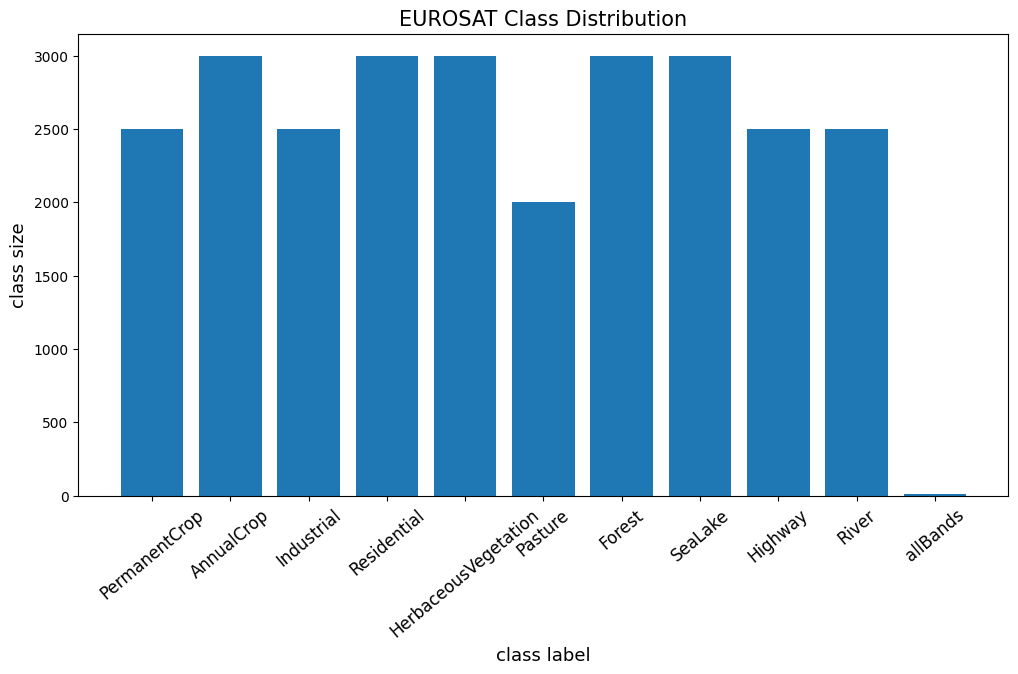

In [5]:
# plot class distributions of whole dataset
counts = {}

# Get the list of actual class directories within the LABELS path
# We need to filter out the files (csv, json) and only keep directories
class_dirs = [d for d in os.listdir(LABELS) if os.path.isdir(os.path.join(LABELS, d))]

for class_name in class_dirs:
    class_path = os.path.join(LABELS, class_name)
    counts[class_name] = len(os.listdir(class_path))


plt.figure(figsize=(12, 6))

plt.bar(range(len(counts)), list(counts.values()), align='center')
plt.xticks(range(len(counts)), list(counts.keys()), fontsize=12, rotation=40)
plt.xlabel('class label', fontsize=13)
plt.ylabel('class size', fontsize=13)
plt.title('EUROSAT Class Distribution', fontsize=15);

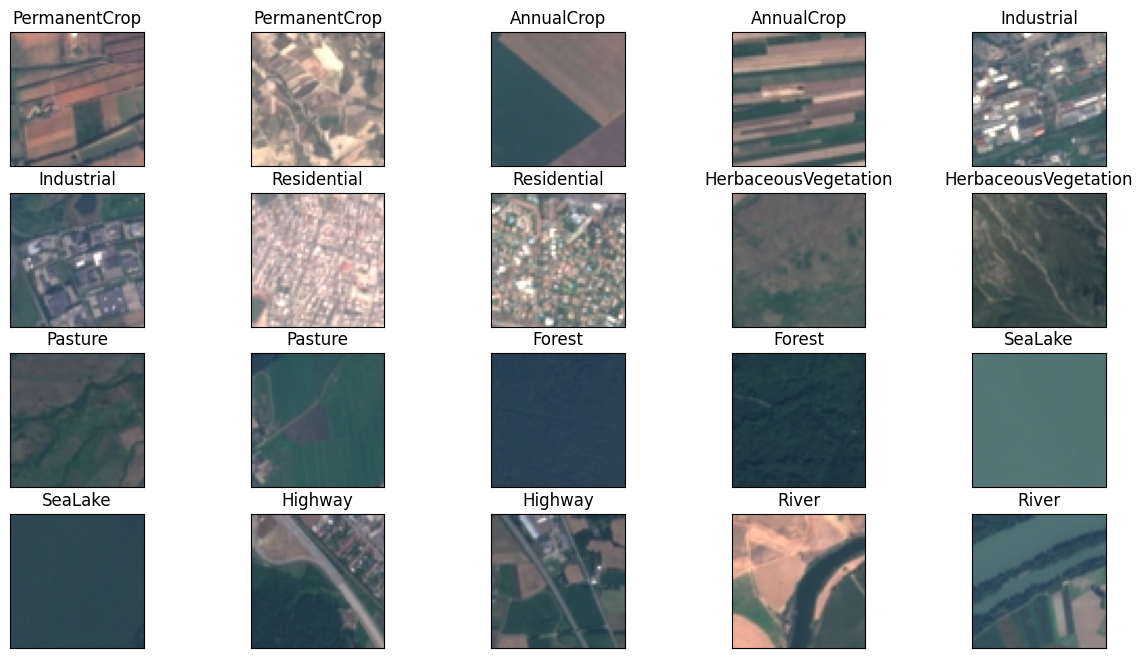

In [6]:
import PIL.Image # Import the Pillow library

img_paths = []
# Collect a couple of image paths from each class directory for plotting
for class_name in class_dirs:
    class_path = os.path.join(LABELS, class_name)
    # List all files in the class directory and filter for common image extensions
    files_in_class = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    image_files = [f for f in files_in_class if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))] # Added .tif/.tiff
    # Add up to 2 image paths from each class to the list for plotting
    for i in range(min(2, len(image_files))):
        img_paths.append(os.path.join(class_path, image_files[i]))

def plot_sat_imgs(paths):
    plt.figure(figsize=(15, 8))
    # Plot up to 20 images from the collected paths
    for i in range(min(20, len(paths))): # Ensure we don't go out of bounds
        plt.subplot(4, 5, i+1, xticks=[], yticks=[])
        try:
            img = PIL.Image.open(paths[i], 'r')
            # Attempt to convert to RGB for consistent display, especially for multi-band TIFFs
            # Note: This is a simplification; for full 13-band data processing, specialized libraries like rasterio/GDAL might be needed.
            if img.mode != 'RGB':
                img = img.convert('RGB')
            plt.imshow(np.asarray(img))
            plt.title(paths[i].split('/')[-2])
        except Exception as e:
            plt.title(f"Error loading {os.path.basename(paths[i])}\nClass: {paths[i].split('/')[-2]}", fontsize=9, color='red')
            plt.text(0.5, 0.5, "Failed to load", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color='red', fontsize=10)
            print(f"Warning: Could not load or process image {paths[i]}: {e}")

plot_sat_imgs(img_paths)

# II. Preprocessing

In [7]:
IMG_SIZE = (224, 224)   # Required for ResNet50
BATCH_SIZE = 64

In [8]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,   # 80-20 split
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [9]:
data_dir = LABELS # Define data_dir

# Define the list of actual class directories to include
good_class_names = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and d != 'allBands']

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=good_class_names
)

Found 21600 images belonging to 10 classes.


In [10]:
val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=good_class_names
)

Found 5400 images belonging to 10 classes.


In [11]:
print(train_generator.class_indices)

{'PermanentCrop': 0, 'AnnualCrop': 1, 'Industrial': 2, 'Residential': 3, 'HerbaceousVegetation': 4, 'Pasture': 5, 'Forest': 6, 'SeaLake': 7, 'Highway': 8, 'River': 9}


In [12]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (64, 224, 224, 3)
Label batch shape: (64, 10)


## III. Model Definition and Compilation

In [13]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [14]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import CategoricalCrossentropy

# Load base model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze most layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head (regularized)
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)

# Output layer (important for mixed precision)
predictions = Dense(
    train_generator.num_classes,
    activation='softmax',
    dtype='float32'
)(x)

# Build model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile with better settings
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,778,890 (94.52 MB)

 Trainable params: 1,187,082 (4.53 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks,
    workers=4,
    use_multiprocessing=True
)

Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 430s 1s/step - accuracy: 0.6126 - loss: 2.6780 - val_accuracy: 0.8896 - val_loss: 1.9576
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 369s 1s/step - accuracy: 0.7990 - loss: 2.1747 - val_accuracy: 0.9152 - val_loss: 1.8710
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.8427 - loss: 2.0451 - val_accuracy: 0.9228 - val_loss: 1.8060
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 363s 1s/step - accuracy: 0.8631 - loss: 1.9541 - val_accuracy: 0.9341 - val_loss: 1.7574
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.8831 - loss: 1.8769 - val_accuracy: 0.9413 - val_loss: 1.6987
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.8909 - loss: 1.8138 - val_accuracy: 0.9404 - val_loss: 1.6511
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.9031 - loss: 1.7439 - val_accuracy: 0.9456 - val_loss: 1.5939
Epoch 8/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.9101 - loss: 1.6806 - val_accu

In [16]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [17]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 428s 1s/step - accuracy: 0.9236 - loss: 1.0373 - val_accuracy: 0.9546 - val_loss: 0.9062 - learning_rate: 1.0000e-05
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 375s 1s/step - accuracy: 0.9406 - loss: 0.9512 - val_accuracy: 0.9622 - val_loss: 0.8723 - learning_rate: 1.0000e-05
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 383s 1s/step - accuracy: 0.9483 - loss: 0.9172 - val_accuracy: 0.9661 - val_loss: 0.8544 - learning_rate: 1.0000e-05
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 383s 1s/step - accuracy: 0.9534 - loss: 0.8920 - val_accuracy: 0.9659 - val_loss: 0.8365 - learning_rate: 1.0000e-05
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.9577 - loss: 0.8719 - val_accuracy: 0.9702 - val_loss: 0.8263 - learning_rate: 1.0000e-05
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - accuracy: 0.9613 - loss: 0.8551 - val_accuracy: 0.9709 - val_loss: 0.8173 - learning_rate: 1.0000e-05
Epoch 7/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - acc

In [22]:
model.save('eurosat_resnet50.keras')

In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
from sklearn.metrics import classification_report

Found 27000 images belonging to 10 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


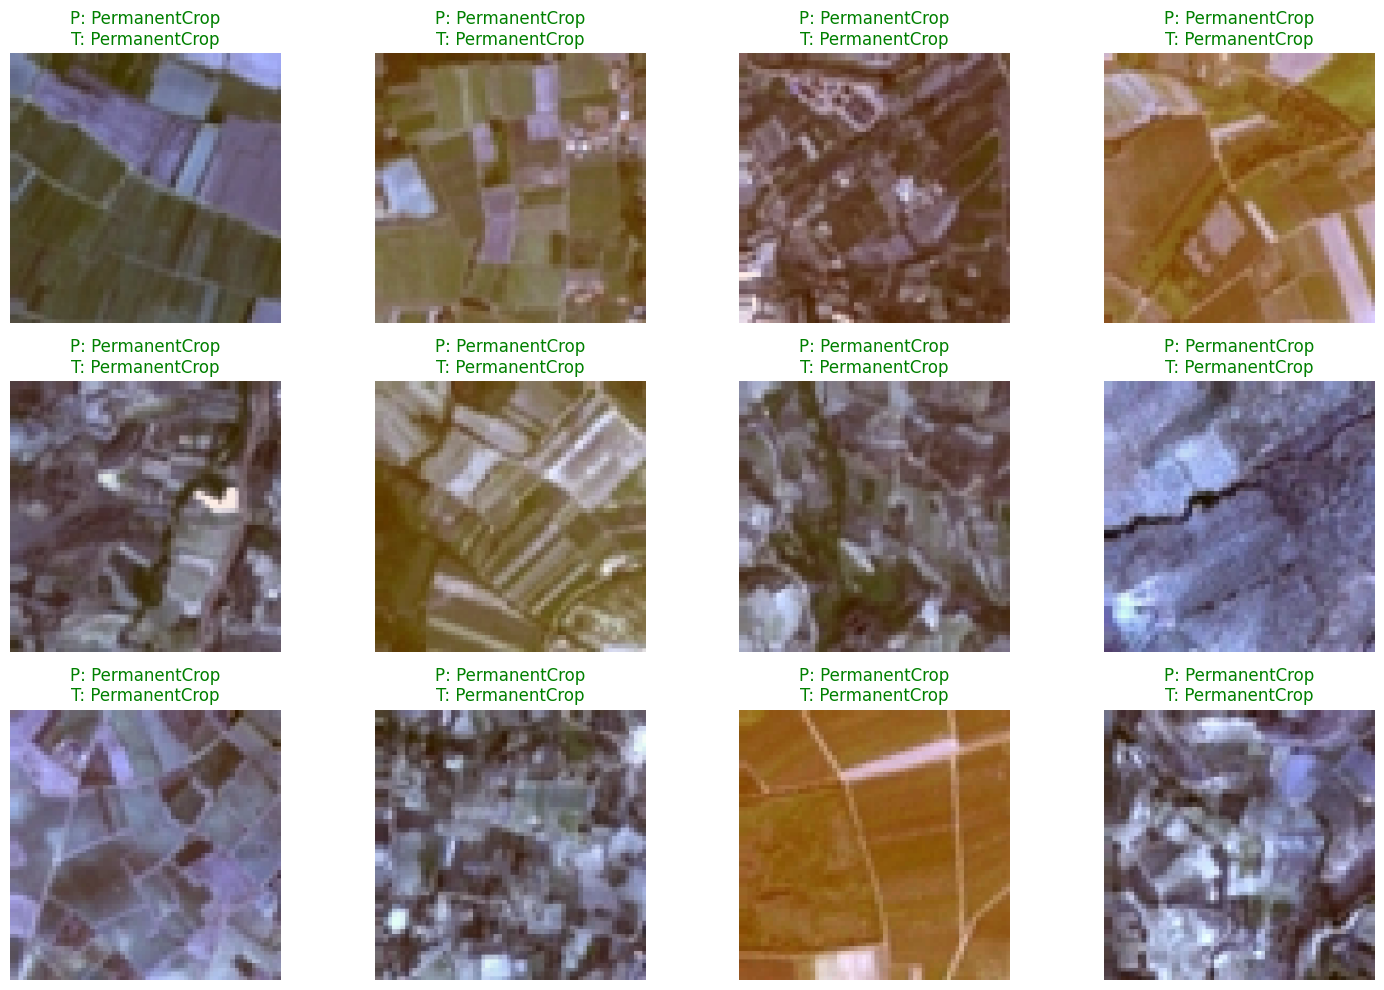

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Import necessary classes for ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Create a separate ImageDataGenerator for testing (no augmentation, no validation split)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Define the test_generator
test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # Set to False for consistent evaluation/testing
    classes=good_class_names
)

# Get a batch of test images
images, labels = next(test_generator)

# Predict
preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(labels, axis=1)

class_names = list(test_generator.class_indices.keys())

# Plot
plt.figure(figsize=(15, 10))

for i in range(12):  # show 12 images
    plt.subplot(3, 4, i+1)

    # Denormalize image for display
    # The preprocess_input for ResNet50 usually subtracts mean and scales
    # A simple denormalization for display is to scale back to 0-255 range
    img_to_display = (images[i] - images[i].min()) / (images[i].max() - images[i].min()) * 255
    img_to_display = img_to_display.astype(np.uint8)

    plt.imshow(img_to_display)
    plt.axis('off')

    pred = class_names[pred_classes[i]]
    true = class_names[true_classes[i]]

    color = 'green' if pred == true else 'red'

    plt.title(f"P: {pred}\nT: {true}", color=color)

plt.tight_layout()
plt.show()

In [30]:
import numpy as np

# Get predictions
y_pred = model.predict(test_generator)

# Convert to class indices
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

422/422 ━━━━━━━━━━━━━━━━━━━━ 90s 200ms/step


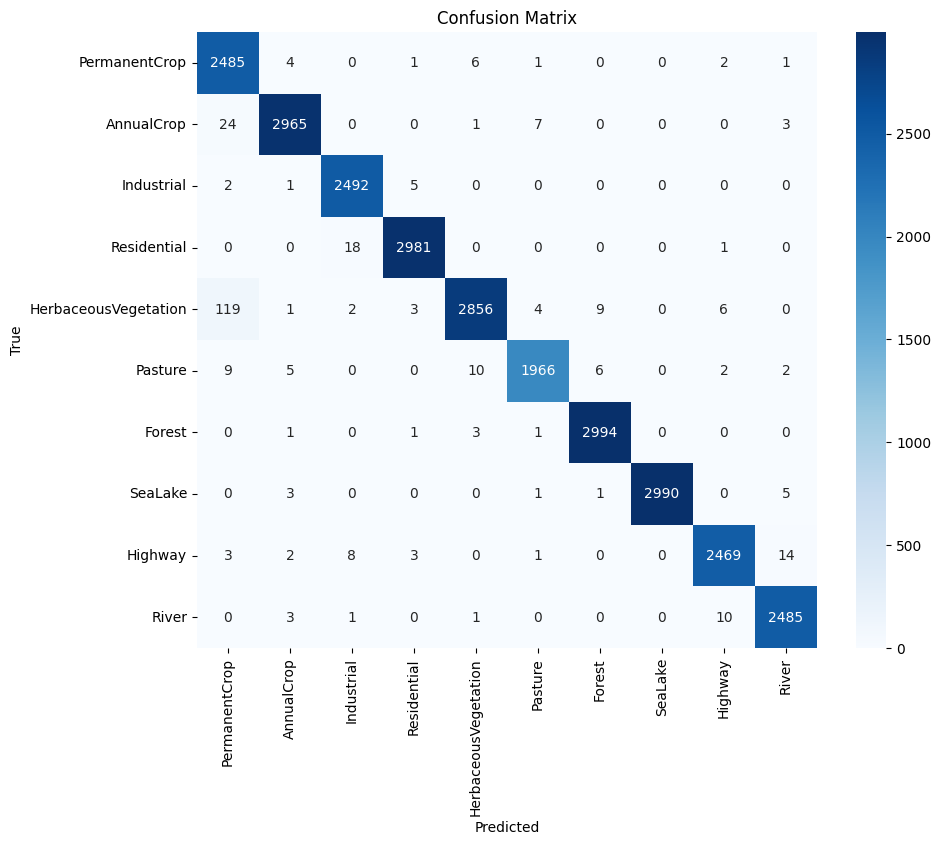

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [33]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred_classes, target_names=class_names)
print(report)

                      precision    recall  f1-score   support

       PermanentCrop       0.94      0.99      0.97      2500
          AnnualCrop       0.99      0.99      0.99      3000
          Industrial       0.99      1.00      0.99      2500
         Residential       1.00      0.99      0.99      3000
HerbaceousVegetation       0.99      0.95      0.97      3000
             Pasture       0.99      0.98      0.99      2000
              Forest       0.99      1.00      1.00      3000
             SeaLake       1.00      1.00      1.00      3000
             Highway       0.99      0.99      0.99      2500
               River       0.99      0.99      0.99      2500

            accuracy                           0.99     27000
           macro avg       0.99      0.99      0.99     27000
        weighted avg       0.99      0.99      0.99     27000

